In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [9]:
load_dotenv()

True

In [10]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

In [11]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str


In [12]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    prompt = f'Generate a detailed outline for a blog on the given topic - {title}'
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state


In [13]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f'Write a detailed blog based on the title - {title} using the following outline \n {outline}'
    content = model.invoke(prompt).content
    state['content'] = content
    return state

In [14]:
graph = StateGraph(BlogState)
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)
workflow = graph.compile()

In [15]:
initial_state = {'title': 'Rise of AI in India'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'Rise of AI in India', 'outline': 'Here\'s a detailed outline for a blog post on "The Rise of AI in India," designed to be engaging, informative, and well-structured.\n\n---\n\n## Blog Title Options:\n\n*   **India\'s AI Ascent: Driving Innovation and Transformation**\n*   **From Silicon Valley to Silicon Bharat: The Meteoric Rise of AI in India**\n*   **Unleashing Potential: How AI is Reshaping India\'s Future**\n*   **The AI Revolution is Here: India\'s Journey to a Tech-Powered Tomorrow**\n\n---\n\n## Blog Outline: India\'s AI Ascent: Driving Innovation and Transformation\n\n### I. Introduction (Approx. 150-200 words)\n\n*   **A. Hook:** Start with a compelling statement about the global AI revolution and its pervasive impact.\n    *   *Example:* "Artificial Intelligence is no longer a futuristic concept; it\'s a present-day reality rapidly reshaping industries, economies, and daily lives across the globe."\n*   **B. Narrow Down to India:** Introduce India\'s unique positi

In [17]:
print(final_state['outline'])

Here's a detailed outline for a blog post on "The Rise of AI in India," designed to be engaging, informative, and well-structured.

---

## Blog Title Options:

*   **India's AI Ascent: Driving Innovation and Transformation**
*   **From Silicon Valley to Silicon Bharat: The Meteoric Rise of AI in India**
*   **Unleashing Potential: How AI is Reshaping India's Future**
*   **The AI Revolution is Here: India's Journey to a Tech-Powered Tomorrow**

---

## Blog Outline: India's AI Ascent: Driving Innovation and Transformation

### I. Introduction (Approx. 150-200 words)

*   **A. Hook:** Start with a compelling statement about the global AI revolution and its pervasive impact.
    *   *Example:* "Artificial Intelligence is no longer a futuristic concept; it's a present-day reality rapidly reshaping industries, economies, and daily lives across the globe."
*   **B. Narrow Down to India:** Introduce India's unique position in this global shift.
    *   *Example:* "While Silicon Valley often

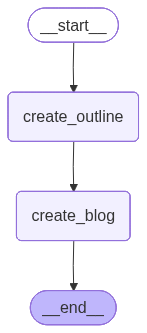

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())